In [1]:
import pandas as pd
import scanpy as sc

In [2]:
adata = sc.read_h5ad("../preprocess/adata_cd8_integrated.h5ad") # it is just cd8.

In [3]:
DATA_DIR = "/home/roger/protocol/cancer-pseudotime-grn-workflow/scripts/data/GSE123813"

tcr_info = pd.read_csv(f"{DATA_DIR}/GSE123813_scc_tcr.txt.gz", sep="\t", index_col=0)

In [4]:
tcr_info

,cdr3s_nt,cdr3s_aa
scc.su010.pre.rep1_AAACGGGAGGACAGAA,TRB:TGTGCCAGCAGCCAAGAGGCGAATGAGCAGTTCTTC,TRB:CASSQEANEQFF
scc.su010.pre.rep1_AAACGGGGTAGTACCT,TRB:TGTGCCAGCAGTTTACCTCGTTTTCTAGCCCACGACAATGAG...,TRB:CASSLPRFLAHDNEQFF
scc.su010.pre.rep1_AAACGGGGTGATAAAC,TRB:TGTGCCAGCAGCTTAGCCGCGGGCCGGGACAGTTTCCTTCTT...,TRB:CASSLAAGRDSFLLGANTGELFF
scc.su010.pre.rep1_AAACGGGTCAAAGTAG,TRA:TGTGCAGGTGAGAAAAGCAGCGGAGACAAGCTGACTTTT;TR...,TRA:CAGEKSSGDKLTF;TRA:CAVGSNAGGTSYGKLTF;TRB:CA...
scc.su010.pre.rep1_AAAGATGAGCTAACAA,TRA:TGTGCTGTGGACAACTCTGGGGCTGGGAGTTACCAACTCACTTTC,TRA:CAVDNSGAGSYQLTF
...,...,...
scc.su013.pre_TTTCCTCGTCCATGAT,TRA:TGTGCCGTGACGACGATGATGAGGGATAGCAGCTATAAATTG...,TRA:CAVTTMMRDSSYKLIF;TRB:CASSLDSYEQYF
scc.su013.pre_TTTGCGCGTTGTCTTT,TRA:TGTGCCGTGACGACGATGATGAGGGATAGCAGCTATAAATTG...,TRA:CAVTTMMRDSSYKLIF;TRB:CASSLDSYEQYF
scc.su013.pre_TTTGTCACACGGTAAG,TRA:TGTGCCGTGACGACGATGATGAGGGATAGCAGCTATAAATTG...,TRA:CAVTTMMRDSSYKLIF;TRB:CASSLDSYEQYF
scc.su013.post_CCTACACTCTGAGGGA,TRA:TGTGCCGTGACGACGATGATGAGGGATAGCAGCTATAAATTG...,TRA:CAVTTMMRDSSYKLIF;TRB:CASSLDSYEQYF


In [5]:
import pandas as pd

def extract_chains(seq_string, chain="TRA"):
    if pd.isna(seq_string):
        return []
    
    parts = str(seq_string).split(";")
    vals = [p.split(":", 1)[1] for p in parts if p.startswith(f"{chain}:")]
    return vals

# extract lists first
tcr_info["TRA_nt_list"] = tcr_info["cdr3s_nt"].apply(lambda x: extract_chains(x, "TRA"))
tcr_info["TRB_nt_list"] = tcr_info["cdr3s_nt"].apply(lambda x: extract_chains(x, "TRB"))
tcr_info["TRA_aa_list"] = tcr_info["cdr3s_aa"].apply(lambda x: extract_chains(x, "TRA"))
tcr_info["TRB_aa_list"] = tcr_info["cdr3s_aa"].apply(lambda x: extract_chains(x, "TRB"))

# find maximum number of chains
max_tra_nt = tcr_info["TRA_nt_list"].apply(len).max()
max_trb_nt = tcr_info["TRB_nt_list"].apply(len).max()
max_tra_aa = tcr_info["TRA_aa_list"].apply(len).max()
max_trb_aa = tcr_info["TRB_aa_list"].apply(len).max()

# expand TRA nt
for i in range(max_tra_nt):
    tcr_info[f"TRA{i+1}_nt"] = tcr_info["TRA_nt_list"].apply(
        lambda x: x[i] if len(x) > i else None
    )

# expand TRB nt
for i in range(max_trb_nt):
    tcr_info[f"TRB{i+1}_nt"] = tcr_info["TRB_nt_list"].apply(
        lambda x: x[i] if len(x) > i else None
    )

# expand TRA aa
for i in range(max_tra_aa):
    tcr_info[f"TRA{i+1}_aa"] = tcr_info["TRA_aa_list"].apply(
        lambda x: x[i] if len(x) > i else None
    )

# expand TRB aa
for i in range(max_trb_aa):
    tcr_info[f"TRB{i+1}_aa"] = tcr_info["TRB_aa_list"].apply(
        lambda x: x[i] if len(x) > i else None
    )

In [6]:
common = adata.obs_names.intersection(tcr_info.index)

In [7]:
tcr_info_aligned = tcr_info.reindex(adata.obs_names)
adata.obs = adata.obs.join(tcr_info_aligned)

In [8]:
adata.obs

,patient,treatment,cluster,UMAP1,UMAP2,celltype,n_genes_by_counts,total_counts,total_counts_mt,pct_counts_mt,...,TRB4_nt,TRA1_aa,TRA2_aa,TRA3_aa,TRA4_aa,TRA5_aa,TRB1_aa,TRB2_aa,TRB3_aa,TRB4_aa
scc.su010.pre.rep1_AAACGGGAGGACAGAA,su010,pre,CD8_naive,-4.361540,2.970602,CD8_naive,1322,3095,145,4.684976,...,None,None,None,None,None,None,CASSQEANEQFF,None,None,None
scc.su010.pre.rep1_AAACGGGGTAGTACCT,su010,pre,CD8_naive,-4.597772,2.647269,CD8_naive,1571,3983,113,2.837057,...,None,None,None,None,None,None,CASSLPRFLAHDNEQFF,None,None,None
scc.su010.pre.rep1_AAACGGGTCAAAGTAG,su010,pre,CD8_naive,-4.662498,2.945328,CD8_naive,1745,3805,188,4.940867,...,None,CAGEKSSGDKLTF,CAVGSNAGGTSYGKLTF,None,None,None,CASSFTSGSYEQYF,None,None,None
scc.su010.pre.rep1_AAAGATGAGCTAACAA,su010,pre,CD8_naive,-4.349666,2.745932,CD8_naive,1904,4604,117,2.541268,...,None,CAVDNSGAGSYQLTF,None,None,None,None,None,None,None,None
scc.su010.pre.rep1_AAAGATGAGTGGCACA,su010,pre,CD8_naive,-4.367948,2.880905,CD8_naive,1725,4118,196,4.759592,...,None,CALSEADFGNEKLTF,None,None,None,None,CASSLGTVNTEAFF,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
scc.su014.post_TTCTCAACAACACCCG,su014,post,CD8_eff,-5.303444,0.242320,CD8_eff,1427,3919,67,1.709620,...,None,CATVTTGANSKLTF,None,None,None,None,CASSLEAASSYNEQFF,None,None,None
scc.su014.post_TTTACTGGTGTGACGA,su014,post,CD8_eff,-5.528499,-0.362831,CD8_eff,1090,2571,76,2.956048,...,None,None,None,None,None,None,CASSQTELYGYTF,None,None,None
scc.su014.post_TTTACTGTCACTCCTG,su014,post,CD8_eff,-5.676641,-0.858432,CD8_eff,1380,3346,78,2.331142,...,None,CAETDLGGYNKLIF,None,None,None,None,CASSLGLAGGGQETQYF,None,None,None
scc.su014.post_TTTGGTTTCTTTACGT,su014,post,CD8_mem,-5.674574,-0.213086,CD8_mem,1477,3831,106,2.766902,...,None,CAVLLGAGGSYIPTF,None,None,None,None,CASSSEELGLNYGYTF,None,None,None


In [9]:
tra_cols = [c for c in adata.obs.columns if c.startswith("TRA") and c.endswith("_aa")]
trb_cols = [c for c in adata.obs.columns if c.startswith("TRB") and c.endswith("_aa")]

adata.obs["TRA_set"] = adata.obs[tra_cols].apply(lambda x: set(x.dropna()), axis=1)
adata.obs["TRB_set"] = adata.obs[trb_cols].apply(lambda x: set(x.dropna()), axis=1)

In [10]:
def has_overlap(row1, row2):
    return (
        len(row1["TRA_set"] & row2["TRA_set"]) > 0 or
        len(row1["TRB_set"] & row2["TRB_set"]) > 0
    )

In [11]:
# combine all chains into one set
adata.obs["TCR_set"] = adata.obs.apply(
    lambda r: r["TRA_set"] | r["TRB_set"], axis=1
)

# explode → one row per chain
df = adata.obs["TCR_set"].explode().reset_index()
df.columns = ["cell", "chain"]

# cells sharing same chain
matches_df = df.merge(df, on="chain")
matches_df = matches_df[matches_df["cell_x"] != matches_df["cell_y"]]

matches_df = matches_df[["cell_x", "cell_y"]].drop_duplicates()

In [12]:
match_counts = matches_df["cell_x"].value_counts()
adata.obs["n_matches"] = adata.obs.index.map(match_counts).fillna(0)

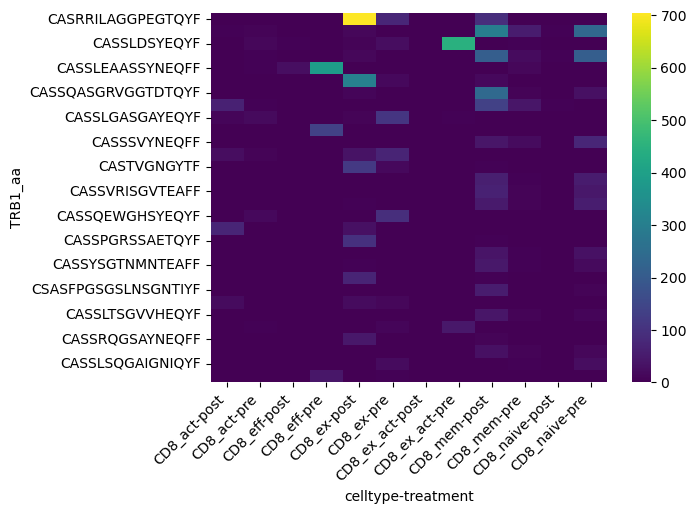

In [13]:
import seaborn as sns
import matplotlib.pyplot as plt

table = pd.crosstab(
    adata.obs["TRB1_aa"],  # TRA2 yes
    [adata.obs["celltype"], adata.obs["treatment"]]
)

# top clones
top = table.sum(axis=1).sort_values(ascending=False).head(30).index

sns.heatmap(table.loc[top], cmap="viridis")
plt.xticks(rotation=45, ha="right")
plt.show()

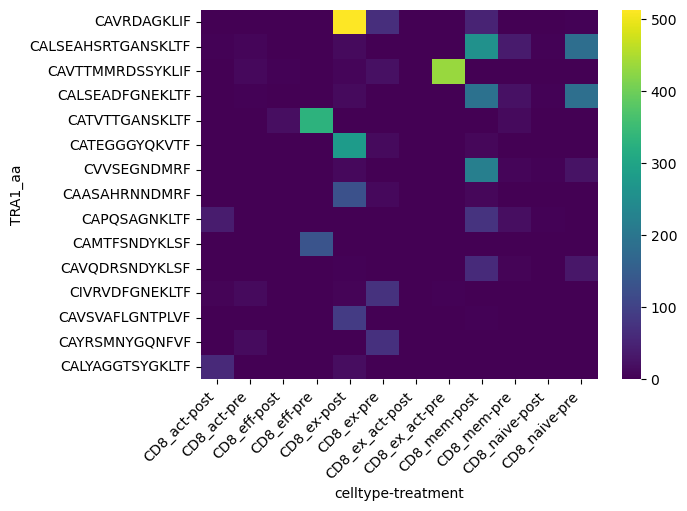

In [57]:
import seaborn as sns
import matplotlib.pyplot as plt

table = pd.crosstab(
    adata.obs["TRA1_aa"],  # TRA2 yes
    [adata.obs["celltype"], adata.obs["treatment"]]
)

# top clones
top = table.sum(axis=1).sort_values(ascending=False).head(15).index

sns.heatmap(table.loc[top], cmap="viridis")
plt.xticks(rotation=45, ha="right")
plt.show()

In [53]:
import pandas as pd

# Make sure values are numeric
trb_counts = table.apply(pd.to_numeric, errors="coerce").fillna(0)

# Number of celltype/treatment columns where each TRB appears
n_columns_present = (trb_counts > 0).sum(axis=1)

# Total number of cells per TRB
n_total_cells = trb_counts.sum(axis=1)

# Create summary table
trb_summary = pd.DataFrame({
    "n_columns_present": n_columns_present,
    "n_total_cells": n_total_cells
})

# Sort by broadest presence first, then most cells
trb_summary = trb_summary.sort_values(
    ["n_columns_present", "n_total_cells"],
    ascending=False
)

trb_summary.sort_values(['n_total_cells'], ascending=False).head(20)

,n_columns_present,n_total_cells
TRA1_aa,,
CAVRDAGKLIF,10,644
CALSEAHSRTGANSKLTF,9,509
CAVTTMMRDSSYKLIF,7,481
CALSEADFGNEKLTF,7,421
CATVTTGANSKLTF,5,367
CATEGGGYQKVTF,4,303
CVVSEGNDMRF,6,268
CAASAHRNNDMRF,3,149
CAPQSAGNKLTF,5,140


In [48]:
import pandas as pd

# Make sure values are numeric
trb_counts = table.apply(pd.to_numeric, errors="coerce").fillna(0)

# Number of celltype/treatment columns where each TRB appears
n_columns_present = (trb_counts > 0).sum(axis=1)

# Total number of cells per TRB
n_total_cells = trb_counts.sum(axis=1)

# Create summary table
trb_summary = pd.DataFrame({
    "n_columns_present": n_columns_present,
    "n_total_cells": n_total_cells
})

# Sort by broadest presence first, then most cells
trb_summary = trb_summary.sort_values(
    ["n_columns_present", "n_total_cells"],
    ascending=False
)

trb_summary.sort_values(['n_total_cells'], ascending=False).head(20)

,n_columns_present,n_total_cells
TRB1_aa,,
CASRRILAGGPEGTQYF,10,882
CASSLGLVQPQHF,9,619
CASSLDSYEQYF,7,497
CASSLGTVNTEAFF,8,456
CASSLEAASSYNEQFF,5,430
CASGLAGYNEQFF,4,336
CASSQASGRVGGTDTQYF,5,284
CASSLPSGGSRSTDTQYF,6,251
CASSLGASGAYEQYF,7,148


In [14]:
# so we already know that the trajectories are different, so it makes sense to look at it before and after, and we can track a clonotype
# from mem-post to ex-post so it means that it probably is a trajectory, so it matches the outcome...

# we need to comprovate everything and see if this makes some kind of sense or what?

In [15]:
# it seems that naive pre and mem_post also share a lot of clonotypes, this means that we could suggest that they can be the "naive" population...

In [16]:
# what if mem post have come from naive pre and this could be amazing...

In [17]:
# can we map the clonotypes on the umap, then would be nice to see it. 

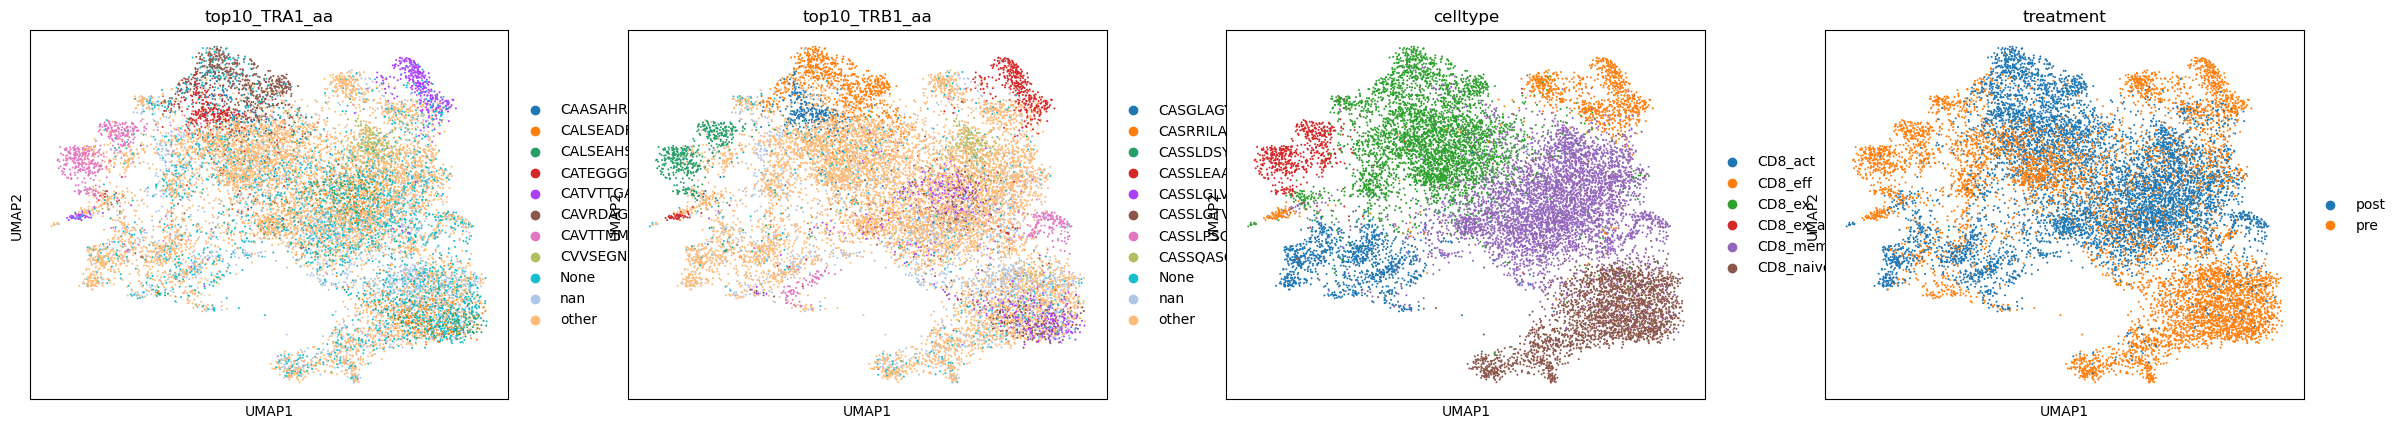

In [18]:
import scanpy as sc

for clonotype in ["TRA1_aa", "TRB1_aa"]:
    top10 = adata.obs[clonotype].astype(str).value_counts().head(10).index

    adata.obs[f"top10_{clonotype}"] = adata.obs[clonotype].astype(str).where(
        adata.obs[clonotype].astype(str).isin(top10),
        other="other"
    ).astype("category")

sc.pl.umap(
    adata,
    color=["top10_TRA1_aa", "top10_TRB1_aa", "celltype", "treatment"]
)

In [25]:
adata.obs['TRB_set']

scc.su010.pre.rep1_AAACGGGAGGACAGAA         {CASSQEANEQFF}
scc.su010.pre.rep1_AAACGGGGTAGTACCT    {CASSLPRFLAHDNEQFF}
scc.su010.pre.rep1_AAACGGGTCAAAGTAG       {CASSFTSGSYEQYF}
scc.su010.pre.rep1_AAAGATGAGCTAACAA                     {}
scc.su010.pre.rep1_AAAGATGAGTGGCACA       {CASSLGTVNTEAFF}
                                              ...         
scc.su014.post_TTCTCAACAACACCCG         {CASSLEAASSYNEQFF}
scc.su014.post_TTTACTGGTGTGACGA            {CASSQTELYGYTF}
scc.su014.post_TTTACTGTCACTCCTG        {CASSLGLAGGGQETQYF}
scc.su014.post_TTTGGTTTCTTTACGT         {CASSSEELGLNYGYTF}
scc.su014.post_TTTGTCATCATGCAAC         {CASSQDLGGGGNTIYF}
Name: TRB_set, Length: 14385, dtype: object

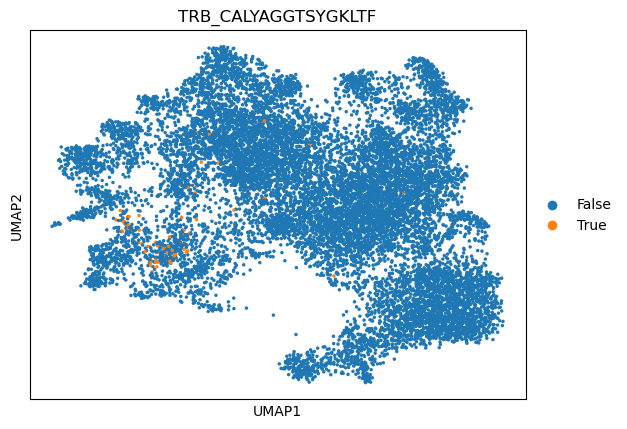

In [58]:


target_trb = "CAPQSAGNKLTF" # es com el da dalt, mem to act...
target_trb = "CAVRDAGKLIF"
target_trb = "CALYAGGTSYGKLTF"

adata.obs[f"TRB_{target_trb}"] = adata.obs["TRA_set"].apply(
    lambda x: target_trb in x if isinstance(x, set) else target_trb in str(x)
)

adata.obs[f"TRB_{target_trb}"].value_counts()

sc.pl.umap(
    adata,
    color=[f"TRB_{target_trb}"],
    groups=[True],
    size=25
)

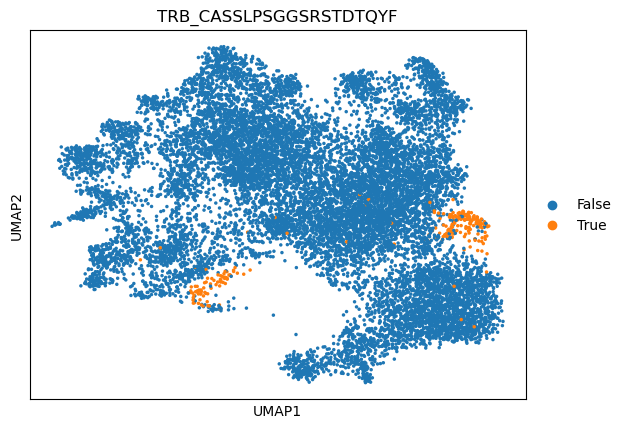

In [51]:
# veig que n'hi ha molts de Naive Pre, i Mem Post, per tant, també es bo que settegem la root a memory quan es post.
# i podem confirmar-ho a partir d'algun TCR interessant...

CAPQSAGNKLTF 	
# aquest es espectacular la veritat!!!
target_trb = "CASSLGLVQPQHF"
target_trb = "CASSLGTVNTEAFF"  #tambe bo naive to mem
target_trb = "CASSQASGRVGGTDTQYF" # mem i se'n va cap a exhausted, pot ser bo.
target_trb = "CASSLGASGAYEQYF" # aquest es bo també, d'act se'n va cap a exhausted
target_trb = "CASSLPSGGSRSTDTQYF"  # de mem se'n va cap a activated, això brutal!!

adata.obs[f"TRB_{target_trb}"] = adata.obs["TRB_set"].apply(
    lambda x: target_trb in x if isinstance(x, set) else target_trb in str(x)
)

adata.obs[f"TRB_{target_trb}"].value_counts()

sc.pl.umap(
    adata,
    color=[f"TRB_{target_trb}"],
    groups=[True],
    size=25
)

In [27]:
target_trb = "CASRRILAGGPEGTQYF"

adata.obs[f"TRB_{target_trb}"] = adata.obs["TRB_set"].apply(
    lambda x: target_trb in x if isinstance(x, set) else target_trb in str(x)
)

adata.obs[f"TRB_{target_trb}"].value_counts()

TRB_CASRRILAGGPEGTQYF
False    13469
True       916
Name: count, dtype: int64

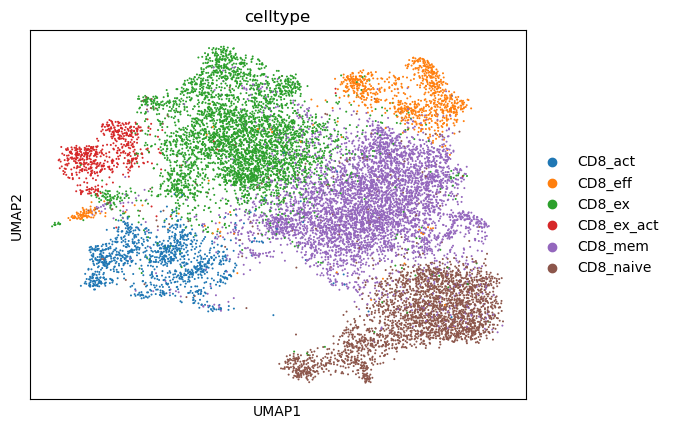

In [32]:
sc.pl.umap(adata, color = ['celltype'] )

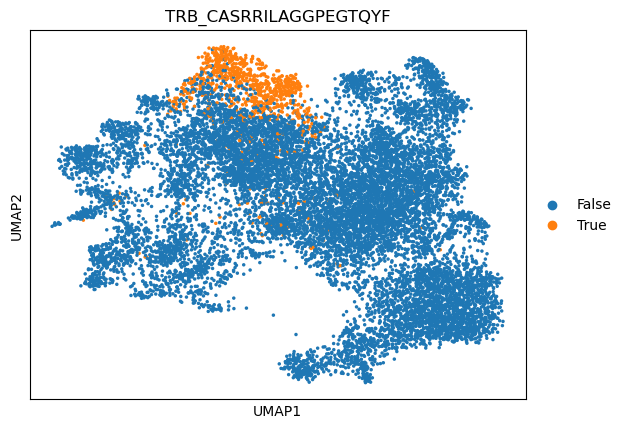

In [31]:
sc.pl.umap(
    adata,
    color=[f"TRB_{target_trb}"],
    groups=[True],
    size=25
)

TypeError: unhashable type: 'set'

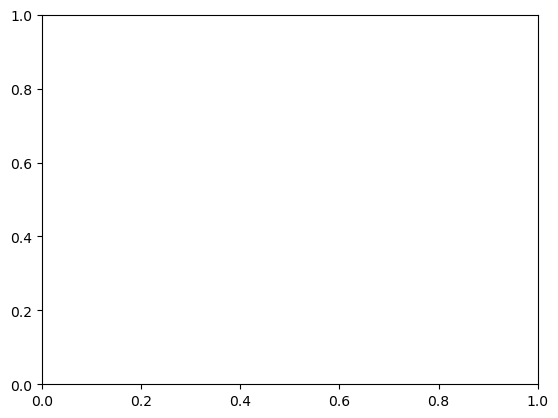

In [26]:
sc.pl.umap(adata, color=[{"CASRRILAGGPEGTQYF"}])

In [19]:
top

Index(['CASRRILAGGPEGTQYF', 'CASSLGLVQPQHF', 'CASSLDSYEQYF', 'CASSLGTVNTEAFF',
       'CASSLEAASSYNEQFF', 'CASGLAGYNEQFF', 'CASSQASGRVGGTDTQYF',
       'CASSLPSGGSRSTDTQYF', 'CASSLGASGAYEQYF', 'CASSQTELYGYTF',
       'CASSSVYNEQFF', 'CASSAGPRGADTQYF', 'CASTVGNGYTF', 'CASSLGQGGSLWANVLTF',
       'CASSVRISGVTEAFF', 'CASSFTSGSYEQYF', 'CASSQEWGHSYEQYF',
       'CASSLGGADRDDEQYF', 'CASSPGRSSAETQYF', 'CASSQEANEQFF',
       'CASSYSGTNMNTEAFF', 'CASSLEIAGGGSYGYTF', 'CSASFPGSGSLNSGNTIYF',
       'CASSATSGGLDTQYF', 'CASSLTSGVVHEQYF', 'CASSRERNTEAFF',
       'CASSRQGSAYNEQFF', 'CASSEALAGRSTDTQYF', 'CASSLSQGAIGNIQYF',
       'CASSQGGEALKYF'],
      dtype='object', name='TRB1_aa')